# CMDA Project
------------
## Project Title: Stock Attributes and Correlation Analysis of Stock Valuations
**Team Members:**
* Dylan Munitz
* Charles Liu
* Aarushi Sinha
* Ella WIlliams
* Shreyas Bera

**Team Member PIDs:**
* 9065-43274
* 9065-52347
* 9065-36880
* 9065-49382
* 9063-90155 (shreyas21)


**Team Name:** Stock Guessers



## Project Introduction

**Topic:** Analysis of Overvalued/Undervalued stocks
**Research Questions:**
* Can You Identify Overvalued and Undervalued Stocks Using Financial Ratios/Stock Metrics?
* Can we see if the companies related to each other based on their financial attributes?
* Can technical analysis(RSI) correctly predict price based on our Overvalued/Undervalued model?
* Do stocks in the same sector also appear in similar clusters?
* Can we reccomend similar stocks when we find a stock is being overvalued?



**Process:**
1) Pull all stock data stockanalysis.com. Then find other .csv files containing other information that it would help analysis
    and merge the datasets together. 
3)  Only looking at companies that have a market cap of over $1 billion as of market close on April 10, 2025
4)  Filtering and creating lists of undervalued/overvalued stocks
5)  Linear Regression to find predicted price
6)  KMeans clustering to cluster companies with similar financial attributes
7)  Cosine Analysis on the Overvalued stocks

--------

## Credit Listing:
* Charles: Collected, cleaned, and normalized data
* Dylan: Graph and Document Formattting
* Aarushi: Simple Linear Regression
* Ella: Multiple Linear Regression
* Shreyas: Clustering and Websraping

### Hook & Intro (WIP)

Ideas: 
* Something about the recent sharp falls and rises in the stock market. A need to understand stock evaluation and knowing when stocks are over/under evaluated

* Reason: As students we want to be financially independent and many of us are interested in stocks and the market


(Hook stuff) ... many students watch the stock ticker. But how can we best know what we are actually looking at? Investing has become more accessible to us as students.... 

Currently in the United States there are ____ trillions of dollars in the US economy. Of that, ____ % or _____ trillion is in the US stock market. 


#### What are Overvalued and Undervalued Stocks?

When a stock is considered to be overvalued, it means

#### Pros and Cons of Overvalued and Undervalued Stocks

__Overvalued:__
* Pros:
    * d
    * 
* Cons:
    * d
    * 

__Undervalued:__
* Pros:
    * d
    * 
* Cons:
    * d
    *  

#### Why does this Matter for Beginners in Investing? 

When we are first learning to invest and make money on the stock market, it is best for begginers to have safe stocks with realtively lower risks. A stock that is not properly valued can potentially harm begginner investors because

In [4]:
import pandas as pd
import os
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
os.environ["OMP_NUM_THREADS"] = "1" #or visuals

## Load in datasets

**Data Links:**

Due to the length and complexity of scraping the dataset from websites, we found it best to grab the data from different sources and join them together. 

* Stock Analysis: All Quantitative data from after market close on April 10th, 2025
    * source: https://stockanalysis.com/stocks/screener/
      
* Symbols: Contains categorical data for stocks. This contains information on 
    * source: https://github.com/dhhagan/stocks/blob/master/scripts/stock_info.csv
      
* Top 1000 of 2025: A dataset created using Janruary 1, 2025 data. This data was webscraped and was used to estimate the amount of clusters for the larger data given by stock analysis. 
    * source: https://disfold.com/world/companies/



## 

In [7]:
data1 = pd.read_csv("CMDA_Project1_Data_Part1.csv") # from stockanalysis.com
data2 = pd.read_csv("CMDA_Project1_Data_Part2_New.csv") 
symbols = pd.read_csv("stock_info.csv") #https://github.com/dhhagan/stocks/blob/master/scripts/stock_info.csv

temp = pd.read_csv("temp.csv") #temporary data so I can continue working on clustering. Will be fixed with new data when it comes
temp

,Company,MarketCap,Overvalued,Sector,Country,Exchange,PB
0,A,28491,1,Food,China,NASDAQ,1.2
1,B,19203,1,Hospitality,USA,NASDAQ,1.3
2,C,19294,0,Energy,France,NASDAQ,1.0
3,D,18485,0,Energy,France,NYSE,1.0
4,E,294,0,Hospitality,USA,NYSE,1.0
5,F,8931,0,Energy,USA,NYSE,1.0
6,G,57262,1,Film,USA,NYSE,1.9


## Joining and Cleaning the Data

The data is already cleaned up by the website and doesn't require any major cleaning other than removing some symbols

In [9]:
#join
data = pd.merge(data1, data2, how='inner', left_on='Symbol', right_on = 'Symbol')
data.head()

,Symbol,PE Ratio,Market Cap,Forward PE,Forward PS,P/OCF,Fwd EV/S,EV/EBIT,Earnings Yield,Ent. Value,...,Asset Turnover,F-Score,Inv. Turnover,Z-Score,Stock Price,Volume,RSI,RSI (W),RSI (M),EPS
0,MSFT,30.10,2.778970e+12,26.51,9.29,22.13,9.26,23.82,3.34%,2.769639e+12,...,0.51,6,63.46,9.04,381.35,37488366,48.87,40.56,51.75,12.42
1,NVDA,36.36,2.627636e+12,23.90,13.02,41.00,12.86,30.79,2.77%,2.594408e+12,...,1.41,6,4.25,54.03,107.57,432498057,46.37,43.04,59.97,2.94
2,AMZN,32.77,1.920515e+12,28.34,2.70,16.57,2.74,27.50,3.09%,1.950213e+12,...,1.11,7,9.66,5.20,181.22,67499898,42.12,37.78,52.32,5.53
3,META,22.92,1.385810e+12,21.12,7.21,15.17,7.06,19.20,4.50%,1.357055e+12,...,0.67,7,NaN,11.15,546.29,27819437,42.51,42.82,59.04,23.86
4,AVGO,83.43,8.167287e+11,25.28,12.40,38.42,13.27,49.55,1.23%,8.740007e+11,...,0.32,7,10.06,5.83,172.30,51037273,46.42,44.32,59.77,2.08


In [10]:
# fill all NaN with 0s
data = data.fillna(0)

In [11]:
data.dtypes

Symbol                object
PE Ratio             float64
Market Cap           float64
Forward PE           float64
Forward PS           float64
P/OCF                float64
Fwd EV/S             float64
EV/EBIT              float64
Earnings Yield        object
Ent. Value           float64
EV/Sales             float64
EV/EBITDA            float64
P/EBITDA             float64
FCF / EV              object
P/FCF                float64
PS Ratio             float64
PB Ratio             float64
PEG Ratio            float64
EV/Earnings          float64
EV/FCF               float64
FCF Yield             object
P/TBV                float64
Div. Yield            object
Div. Growth           object
Payout Ratio          object
Shareh. Yield         object
Div. ($)             float64
Years                float64
Last Div.            float64
Total Cash           float64
Debt Growth (QoQ)     object
Net Cash             float64
Total Debt           float64
Net Cash Growth       object
Debt Growth (3

In [12]:
#merge the datasets
#merged_df = df.merge(right = data, left = symbols, how='inner', on= '')
symbols = symbols.rename(columns={"Ticker":"Symbol"})
symbols.head()

,Symbol,Name,Exchange
0,A,Agilent Technologies,NYSE
1,AA,Alcoa Inc.,NYSE
2,AAN,Aaron's Inc,NYSE
3,AAT,American Assets Trust,NYSE
4,AAV,Advantage Oil & Gas Ltd,NYSE


In [13]:
merged_df = data.merge(symbols, on='Symbol', how='inner')
merged_df.head()

,Symbol,PE Ratio,Market Cap,Forward PE,Forward PS,P/OCF,Fwd EV/S,EV/EBIT,Earnings Yield,Ent. Value,...,Inv. Turnover,Z-Score,Stock Price,Volume,RSI,RSI (W),RSI (M),EPS,Name,Exchange
0,MSFT,30.10,2.778970e+12,26.51,9.29,22.13,9.26,23.82,3.34%,2.769639e+12,...,63.46,9.04,381.35,37488366,48.87,40.56,51.75,12.42,Microsoft Corp.,NASDAQ
1,NVDA,36.36,2.627636e+12,23.90,13.02,41.00,12.86,30.79,2.77%,2.594408e+12,...,4.25,54.03,107.57,432498057,46.37,43.04,59.97,2.94,Nvidia Corp.,NASDAQ
2,AMZN,32.77,1.920515e+12,28.34,2.70,16.57,2.74,27.50,3.09%,1.950213e+12,...,9.66,5.20,181.22,67499898,42.12,37.78,52.32,5.53,Amazon.Com,NASDAQ
3,AVGO,83.43,8.167287e+11,25.28,12.40,38.42,13.27,49.55,1.23%,8.740007e+11,...,10.06,5.83,172.30,51037273,46.42,44.32,59.77,2.08,Avago Technologies,NASDAQ
4,TSM,21.39,1.543621e+11,2.42,0.04,2.77,0.03,2.52,23.39%,1.086991e+11,...,4.71,3.56,151.13,24422033,38.12,33.92,51.81,6.96,Taiwan Semiconductor Manufacturing,NYSE


In [14]:
#set the index to be the company Symbol
data = data.set_index("Symbol")

Due to the number of objects in the dataframe, we decided to use a for loop to detect any objects. To do this we filtered out columns that were 

In [16]:
#filter columns that are object
for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].str.replace("%", "").astype(float)/100



In [17]:
#All data is numeric now
norm = (data - data.mean()) / data.std()
norm = norm.fillna(0) #as some data have a standard deviation of 0
norm.head()

,PE Ratio,Market Cap,Forward PE,Forward PS,P/OCF,Fwd EV/S,EV/EBIT,Earnings Yield,Ent. Value,EV/Sales,...,Asset Turnover,F-Score,Inv. Turnover,Z-Score,Stock Price,Volume,RSI,RSI (W),RSI (M),EPS
Symbol,,,,,,,,,,,,,,,,,,,,,
MSFT,-0.047357,19.939816,-0.024099,0.034287,-0.008794,0.054500,-0.057160,-0.015559,19.096977,-0.021058,...,-0.193011,0.586437,0.774133,0.116790,-0.002676,2.183520,1.027684,0.058287,0.437793,-0.021715
NVDA,-0.032362,18.842499,-0.035608,0.085443,0.099314,0.117838,-0.034281,-0.023518,17.873423,-0.005621,...,1.216039,0.586437,-0.100510,1.302594,-0.019752,28.531880,0.718938,0.287002,1.094707,-0.028365
AMZN,-0.040961,13.715210,-0.016030,-0.056093,-0.040648,-0.060213,-0.045081,-0.019050,13.375332,-0.033540,...,0.746356,1.234473,-0.020594,0.015579,-0.015158,4.185381,0.194071,-0.198095,0.483345,-0.026548
META,-0.064556,9.838097,-0.047866,0.005760,-0.048669,0.015793,-0.072325,0.000638,9.233606,-0.024925,...,0.057487,1.234473,-0.163291,0.172403,0.007612,1.538573,0.242235,0.266713,1.020384,-0.013691
AVGO,0.080390,5.711721,-0.029523,0.076940,0.084533,0.125051,0.027297,-0.045022,5.860676,-0.012011,...,-0.490478,1.234473,-0.014686,0.032184,-0.015715,3.087274,0.725113,0.405049,1.078723,-0.028968


# QACs

## Can we identify if a company's price is overvalued or undervalued

By definition when a stock is overvalued, 


There are many ways to evaluate if a stock may be overvalued using information given from the stock tickers. The most agreed upon way to classify overvalued stocks is by analyzing price to Earnings (PE), price to Book (PB), and price earning to growth (PEG) ratios. Using these values together can help give us insight on if we can properly classify a stock as overvalued, undervalued, or properly valued. 

sources: 
* https://raseedinvest.com/en/learn/what-does-it-mean-if-a-stock-is-overvalued 

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection  import train_test_split
from sklearn.metrics import mean_squared_error

In [21]:
#remove outliers in price in data, outlier if not within 3 STD
z_scores = (data["Stock Price"] - data["Stock Price"].mean()) / data["Stock Price"].std()
data = data[abs(z_scores) < 3]

#EPS values
z_scores = (data["EPS"] - data["EPS"].mean()) / data["EPS"].std()
data = data[abs(z_scores) < 3]

#market cap
z_scores = (data["Market Cap"] - data["Market Cap"].mean()) / data["Market Cap"].std()
data = data[abs(z_scores) < 3]
data

,PE Ratio,Market Cap,Forward PE,Forward PS,P/OCF,Fwd EV/S,EV/EBIT,Earnings Yield,Ent. Value,EV/Sales,...,Asset Turnover,F-Score,Inv. Turnover,Z-Score,Stock Price,Volume,RSI,RSI (W),RSI (M),EPS
Symbol,,,,,,,,,,,,,,,,,,,,,
TSM,21.39,1.543621e+11,2.42,0.04,2.77,0.03,2.52,0.2339,1.086991e+11,1.22,...,0.47,7,4.71,3.56,151.13,24422033,38.12,33.92,51.81,6.96
KO,28.34,2.997867e+11,22.94,6.09,44.05,6.70,22.39,0.0355,3.297377e+11,7.01,...,0.46,4,4.00,4.44,70.76,17405016,53.63,61.71,61.23,2.46
NVO,19.47,2.489855e+11,2.27,0.72,13.72,0.76,13.65,0.0566,2.604623e+11,6.43,...,0.76,5,1.23,4.86,61.21,9930221,28.89,28.07,33.93,3.16
BABA,15.44,2.527997e+11,1.43,0.24,11.61,0.21,9.89,0.0652,2.224832e+11,1.65,...,0.55,6,0.00,2.89,104.18,44172966,30.92,47.85,51.62,6.84
AZN,28.64,3.995124e+11,14.29,6.82,33.68,7.24,40.68,0.0176,4.241534e+11,7.84,...,0.52,6,1.91,4.66,64.87,9170086,29.80,35.89,45.23,2.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BBSI,19.89,1.017566e+09,17.63,0.82,100.88,0.55,9.65,0.0521,6.850088e+08,0.60,...,1.58,5,0.00,3.58,39.39,178825,41.40,45.42,64.01,1.98
OLO,0.00,1.012699e+09,20.68,3.02,25.52,1.99,3827.29,-0.0009,6.659480e+08,2.34,...,0.39,4,0.00,9.09,6.10,1428647,45.02,44.95,42.87,-0.01
DX,7.43,1.065438e+09,10.29,11.72,74.03,77.07,61.52,0.0997,7.007019e+09,46.59,...,0.02,5,0.00,0.00,11.13,6141035,20.59,31.26,40.74,1.49


In [27]:
industry_df = pd.read_csv("industries_data.csv") #read from our actual file
industry_df.head()

"""
Currently this is 

Country Industry, but we want to just get Industry in sector
"""
industry_df['Sector'] = industry_df['Sector'].str.split().str[-1]

#the total amount of unique sectors in top 1k 
print(len(industry_df.Sector.unique())) 
industry_df.head()

11


,Company,Sector
0,Nvidia Corporation,Technology
1,Apple Inc.,Technology
2,Microsoft Corporation,Technology
3,"Amazon.com, Inc.",Discretionary
4,Alphabet Inc.,Services


### Interactive Clustering using Plotly Go

In the following chart we used plotly to cluster based off the numerical attributes. Then we created buttons from the categorical attributes of the dataset so that one could switch between the visualizations. 


#### Can we Distinguish or Find Trends Between the Countries, Sectors, or Exchanges that Contain Overvalued/Undervalued Stocks?

Understanding if specific countries, sectors/industries, or exchanges tend to have more or less overvalued/undervalued stocks can be a very powerful insight for stockholders. New investors can be overwhelemed by the thousands of stocks available on the NYSE and NASDAQ exchanges. But it may be possible to identify trends and patterns so that we can make good investment decisions and properly understand the risks that may be associated with a category of stocks. 

In [31]:
#needed for plotly to work
import plotly.graph_objects as go


# The code on extracting specific parts from our dataset. After this cell
# we will write code for the actual button and updates

# Read in the temp csv. WIP. To change out later
temp_df = pd.read_csv('temp.csv')

# PCA on market cap on the numerical data. Eventually fix with the actual other numerical data
numerical = temp_df[["MarketCap", "PB"]].fillna(0).values
pca = PCA(n_components=2, random_state=10)
fitted = pca.fit_transform(numerical)

# Data Frame's PC1 and PC2 from our fitted above
temp_df['PC1'] = fitted[:, 0]
temp_df['PC2'] = fitted[:, 1]

# This is to change the marker sizes for visualization. 
# As in making it so that the circle size is based off overvalued vs not overvalued
temp_df['Size'] = temp_df['Overvalued'].map({1:30, 0:10})  # 1 is overvalued. 0 is not overvalued.

# the categories I want to do clustering on. Also the values in each of those categories
categories = ['Country', 'Sector', 'Exchange']
category_values = {cat: list(temp_df[cat].unique()) for cat in categories}

temp_df.head()

,Company,MarketCap,Overvalued,Sector,Country,Exchange,PB,PC1,PC2,Size
0,A,28491,1,Food,China,NASDAQ,1.2,6782.428570,-0.113143,30
1,B,19203,1,Hospitality,USA,NASDAQ,1.3,-2505.571427,0.141797,30
2,C,19294,0,Energy,France,NASDAQ,1.0,-2414.571432,-0.159721,10
3,D,18485,0,Energy,France,NYSE,1.0,-3223.571431,-0.146225,10
4,E,294,0,Hospitality,USA,NYSE,1.0,-21414.571429,0.157234,10


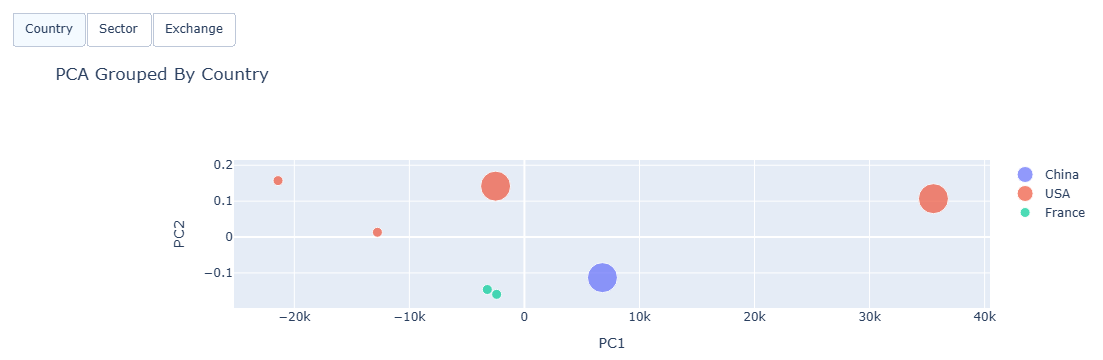

In [32]:
# Create the Interactive Scatter Chart using Plotly Go


"""
I have used plotly go, dash, and express in the past. 
For this I decided to use plotly go as it is better when we have 
multiple traces. I went through the forums and found similar code to the 
one I was trying to do with this

"""
# Create the figure
fig = go.Figure(  )

for c in categories:
    # get only the rows in this category
    for cat in category_values[c]:
        sub_list = temp_df[temp_df[c] == cat]

        # add the traces. Right now there is nothing.
        # This will be a scatter plot, then make the markers use the size and categories
        fig.add_trace(go.Scatter(
            x=sub_list.PC1, # horizontal axis
            y=sub_list.PC2, # vertical axis
            mode='markers',  # the points to draw
            name=str(cat), # the legend values
            marker=dict(size=sub_list['Size']),
            visible=False,  # Make this false so that nothing appears at first. Only should load on the default for country or for when we click a button

            #Decided to hadd hoverdata as it was only showing PCA coordinates
            customdata = sub_list[['Company', 'MarketCap']].values,
            #br is break in html. 
            hovertemplate = "<b>Company: %{customdata[0]}</b><br>" +  #make the company bold and market cap on next line
            "Market Cap: %{customdata[1]:,}<br>"
        ))

# Find the number of traces in each category and their indexes
count = [len(category_values[cat]) for cat in categories]
total = sum(count)  # total number of traces

# index of these pointS
index = [sum(count[:i]) for i in range(len(categories))]

"""
Examples and sources:
https://plotly.com/python/v3/ipython-notebooks/baltimore-vital-signs/
https://medium.com/@twelsh37/python-masking-data-before-plotting-6fd8de196aca 
https://stackoverflow.com/questions/73735818/change-which-traces-are-visible-with-button-and-customdata-python-plotly
https://community.plotly.com/t/plotly-scatter-button-to-select-column-for-colorbar/85702/2 (forum post for something slightly similar)

"""
# Create the buttons
masks = []  # in examples these are called masks. Masks hide the traces until they are actually plotted
for i in range(len(categories)):
    mask = [False] * total
    for j in range(index[i], index[i] + count[i]):
        mask[j] = True
    masks.append(mask)

# Create the Country traces 
for i, trace in enumerate(fig.data):
    trace.visible = masks[0][i]

# Create the button and update the table title when a button is clicked
buttons = []
# https://stackoverflow.com/questions/66414456/update-visibility-of-traces-with-fig-update-layout-plotly 
for i, c in enumerate(categories):
    buttons.append(dict(
        label=c, # The text in the button
        method='update', # update the title and trace 
        args=[
            {'visible': masks[i]}, # Only show the trace we clicked on
            {'title': f'PCA Grouped by {c}'}   # Update the table name
        ]
    ))

"""
Final fixes and updates to the plot/go layout
https://plotly.com/python-api-reference/generated/plotly.graph_objects.Layout.html
https://plotly.com/python/hover-text-and-formatting/
"""
fig.update_layout(
    title="PCA Grouped By Country", #This because Country is the default when we run this cell
    xaxis_title='PC1',
    yaxis_title='PC2',

    updatemenus=[dict(
        # Create all the clickable buttons
        type='buttons',
        direction='right',
        x=0, y=2,       # positioned above the chart
        showactive=True, # highlights/darkens the button we just clicked
        buttons=buttons  # the three buttons in our buttons list
    )],
    margin=dict(l=50, r=50, t=50, b=50), #decided on these margins to make it cleaner
)

# finally show the plot
fig.show()


### Check If our Clustering Makes Sense with What we Would Expect



### Makes sense because

so further analysis....

### Cosine Similarity (WIP)

For reccomending similar stocks or the closest stock that isn't 'this' stock. 

# Possible: Do stocks in the same sector also appear in similar clusters?

(WIP) For right now it appears not always, but we can do more analysis on this


## Data Considerations

~~Our analysis is only a snapshot of data from after the market closed on April 10th, 2025. On this specific day, DOW Jones was down 1000 points. NASDAQ and the S&P 500 also significantly dropped from the day prior. This drop in the stock market could have made the overvalued stocks in our dataset more obvious and easier to identify.~~

Our analysis is only a snapshot of data from after market closed on May 1, 2025. On this specific day, DOW Jones, NASDAQ, and S&P 500 were up before market close on this day. In the previous weeks, CNN labeled the market sentiment as being in "extreme fear". This stemmed in part from a large drop in stock price strength and high market volatility which started on April 1, 2025. 

When the market appears to be doing well, investors will tend to be more optimistic. This can lead to the market sentiment to be considered "bullish" and causes a higher valuation of companies. This can lead to a harder time properly detecting overvalued stocks. The current Fear & Greed Index as of market close was nuetral at 49. An increase of 14 (Fear) from the day before. 


CNN Business' Fear & Greed Index:
https://www.cnn.com/markets/fear-and-greed

Stock Drop:
1) https://medium.com/@wilfredchan_23551/can-candlestick-patterns-make-you-rich-exploring-the-answer-through-machine-learning-1bd290721942#:~:text=In%20summary%2C%20the%20prevailing%20market%20sentiment%20appears,and%20the%20behavior%20of%20the%20moving%20averages.
3) https://www.comparables.ai/articles/analyzing-psychology-behind-investor-perception-of-company-valuations#:~:text=Positive%20market%20sentiment%20can%20drive%20up%20the,them%20to%20assign%20higher%20valuations%20to%20companies.





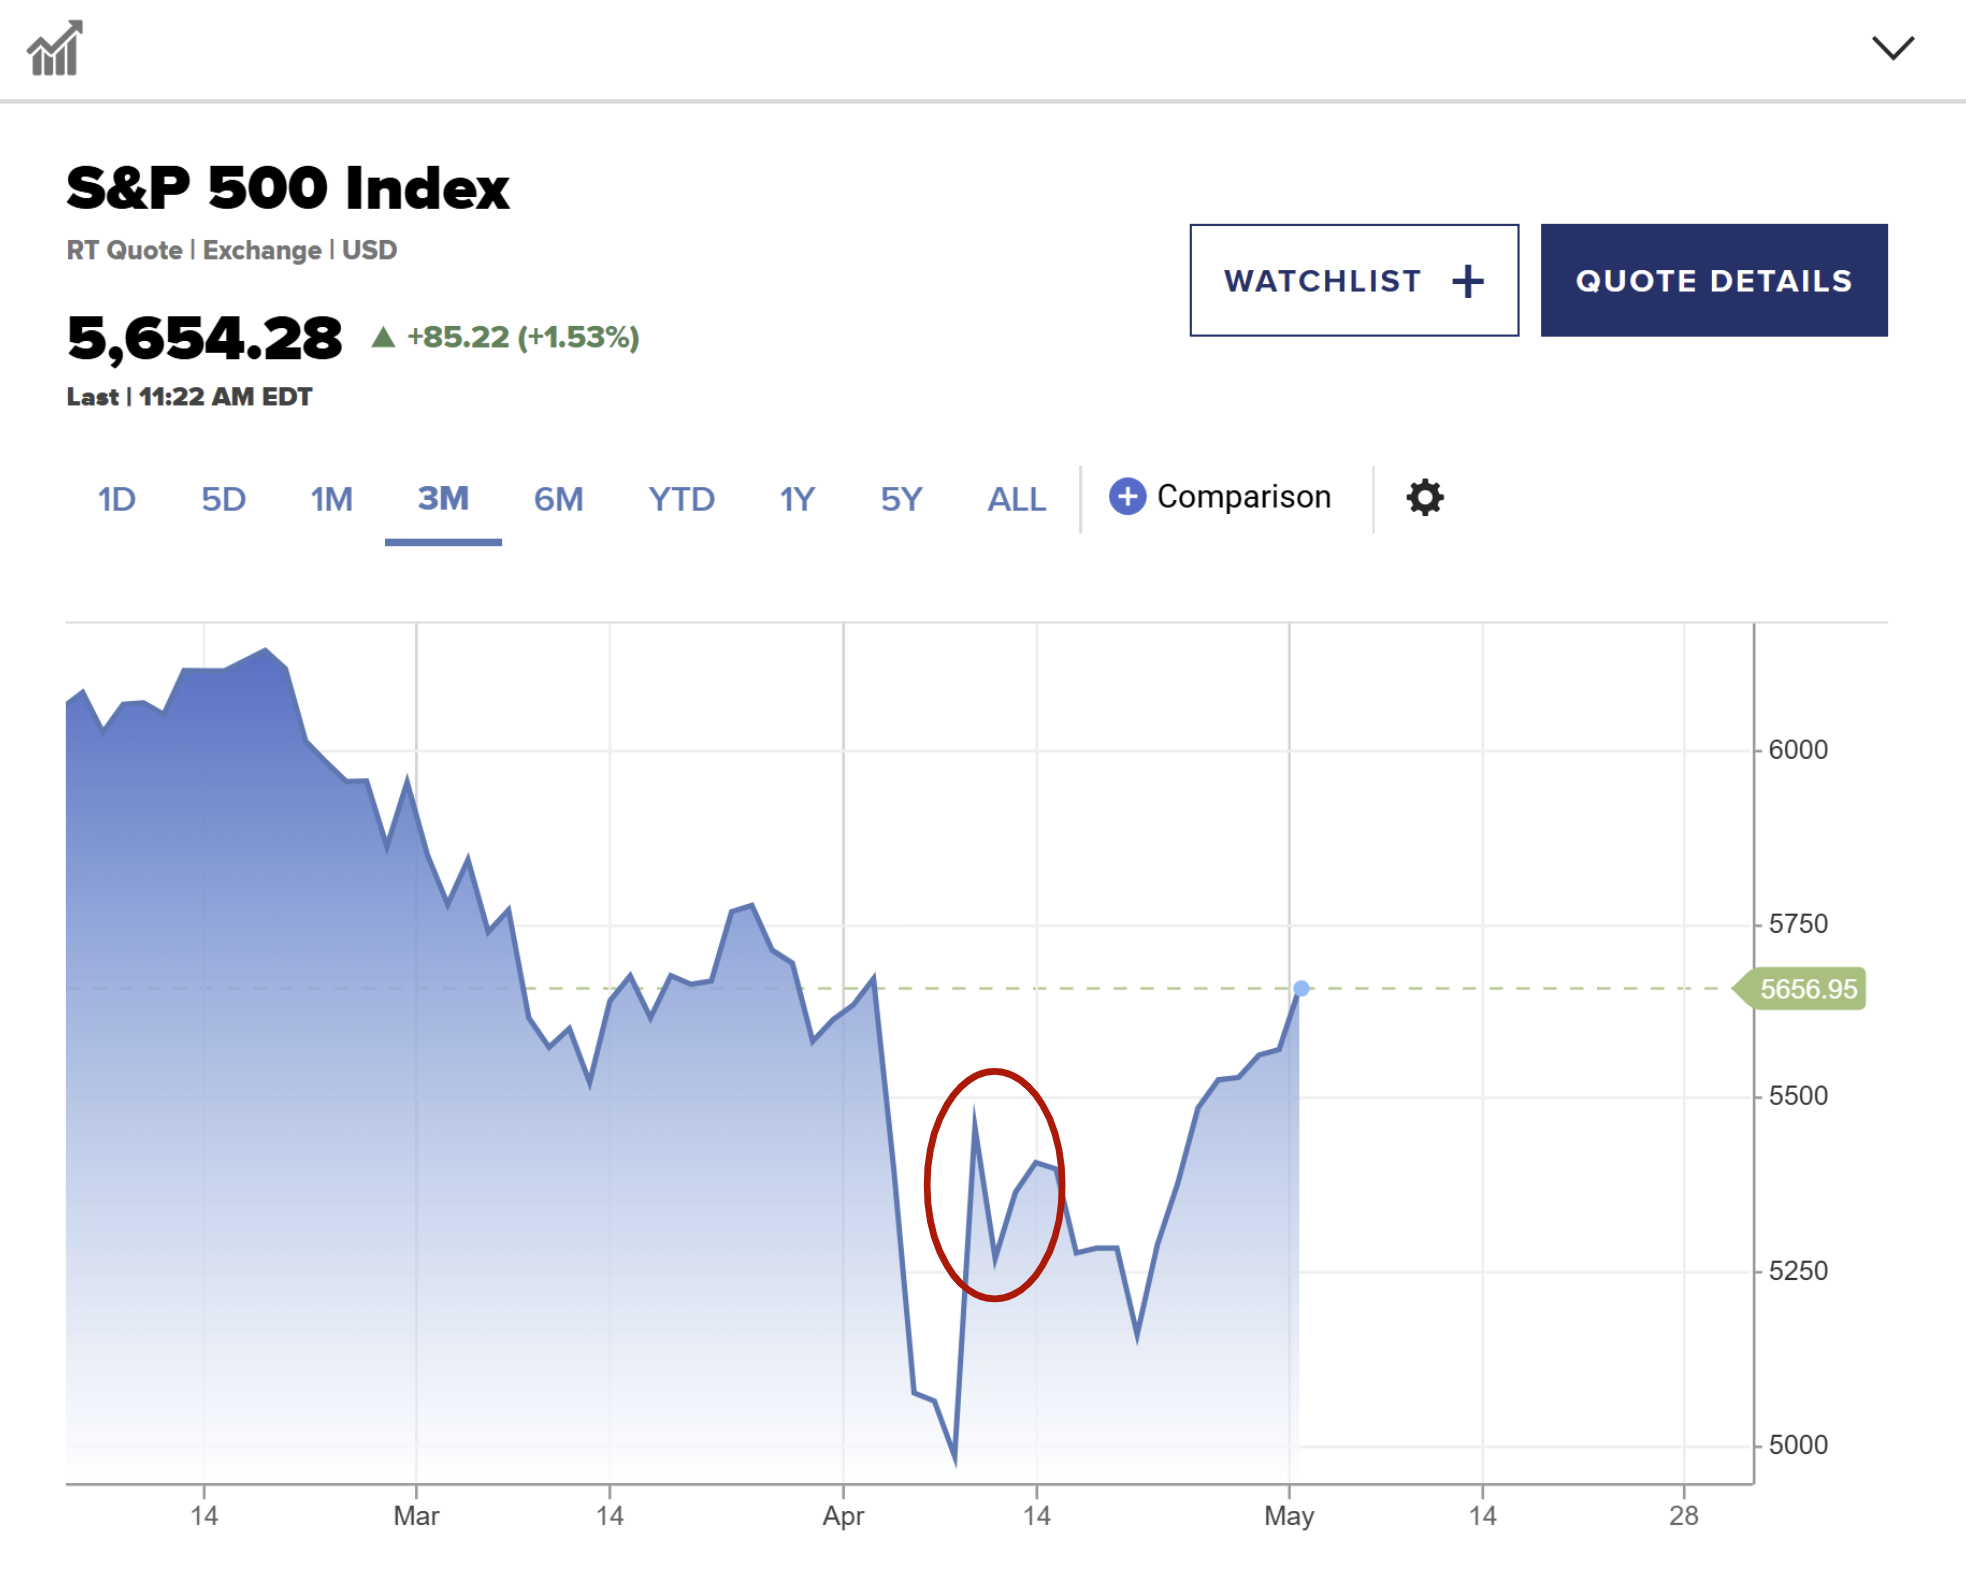

In [39]:
"""
import requests
import bs4
import pandas as pd
import time

# Heavily relied on the beautiful soup documentation 
# https://developer.mozilla.org/en-US/docs/Web/HTML/Reference/Elements
# https://www.w3schools.com/tags/tag_tbody.asp
# using the inspector I found that the table is in a class called "striped", and uses tags:
# tbody, tr, and td

# The header
header = {
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/134.0.0.0 Safari/537.36'
}

#url for the dataset. Will put the page numbers in for loop
base_url = "https://disfold.com/world/companies/?page="

# hold all data in this array
company_data = []

# Loop through pages 1 to 34
for page_num in range(1, 35):
    url = base_url + str(page_num)
    #print out so I know its working and hasn't been stopped
    #this is a really long process
    print(f"Working on page number: {page_num}")
    
    # Get the page and build the BeautifulSoup object
    response = requests.get(url, headers=header)
    soup = bs4.BeautifulSoup(response.text, 'html5lib')
    
    # Locate the table with class "striped" inside the page
    table = soup.find("table", class_="striped")
    
    # When we are in the table
    if table:
        tbody = table.find("tbody") #tbody tag is used to group html tables
        if tbody:
            rows = tbody.find_all("tr") #tr stands for table row
            for row in rows:
                # Each row contains 5 td tags
                cols = row.find_all("td") #td stands for table data

                #sometimes data near the end would be missing a column
                if len(cols) >= 5: #make sure all columns exist. For some reason == made it a blank table

                    #company column
                    company = cols[1].get_text(strip=True)
                    # Sector is in the fifth column
                    sector = cols[4].get_text(strip=True)
                    company_data.append({"Company": company, "Symbol" : symbol, "Sector": sector})
    
    # So that the server doesn't think we are DDos'ing it
    time.sleep(1)

# convert to a dataframe
df = pd.DataFrame(company_data)

#extracts to csvs as this took a really long time to parse
df.to_csv("industries_data.csv", index=False)
"""
''

''